Лабораторная работа: Кластеризация данных (Aggregation Dataset)
Алгоритм: K-Means

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

1. Загрузка и подготовка данных 
Пытаемся загрузить данные из файла. Используем только первые 2 столбца (координаты X и Y)

In [2]:
X = None # Инициализируем X как "ничего"

# Попытка 1: Загрузка из локального файла
try:
    print("Попытка 1: Ищу файл Aggregation.txt в текущей папке...")
    data = np.loadtxt('Aggregation.txt')
    X = data[:, :2]
    print("Успех! Данные загружены из файла.")
except FileNotFoundError:
    print(" Ошибка: Файл 'Aggregation.txt' не найден в текущей папке.")
    print("   Пожалуйста, укажите полный путь к файлу в коде (вариант 2 выше).")
except Exception as e:
    print(f"Произошла ошибка при чтении файла: {e}")

# --- Если X не определен (файл не загрузился), используем "аварийный" вариант ---
if X is None:
    print("\n--- Использую аварийный вариант: Генерация тестовых данных ---")
    print("ВНИМАНИЕ: Это демонстрация. Вам нужно подставить настоящие данные!")
    
    # Генерируем случайные данные, чтобы код не сломался
    # В реальной работе замените это на настоящую загрузку файла
    np.random.seed(42)
    X = np.random.rand(100, 2) * 30 

print(f"\nРазмер данных: {X.shape[0]} точек")

Попытка 1: Ищу файл Aggregation.txt в текущей папке...
Произошла ошибка при чтении файла: could not convert string 'x1' to float64 at row 0, column 1.

--- Использую аварийный вариант: Генерация тестовых данных ---
ВНИМАНИЕ: Это демонстрация. Вам нужно подставить настоящие данные!

Размер данных: 100 точек


2. Настройка параметров K-Means ---
Определяем количество кластеров (K).
Стандартное количество кластеров для набора данных Aggregation - 7.

In [3]:
k = 7  

print(f"Запуск K-Means с K = {k}...")

# Создаем модель K-Means
# random_state=42 - чтобы результаты были воспроизводимы
# n_init=10 - запускаем алгоритм 10 раз с разными центроидами для устойчивости
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) 

# Обучаем модель и получаем метки кластеров для каждой точки
cluster_labels = kmeans_model.fit_predict(X)


Запуск K-Means с K = 7...


c:\Users\User\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\User\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


3. Оценка качества кластеризации

In [4]:
# Вычисляем средний силуэт (Silhouette Score)
# Чем ближе к 1, тем лучше разделение кластеров
silhouette_avg = silhouette_score(X, cluster_labels)
print(f"Средний коэффициент силуэта: {silhouette_avg:.3f}")

Средний коэффициент силуэта: 0.403


4. Визуализация результатов

C:\Users\User\AppData\Local\Temp\ipykernel_8284\1041735788.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('nipy_spectral', k)


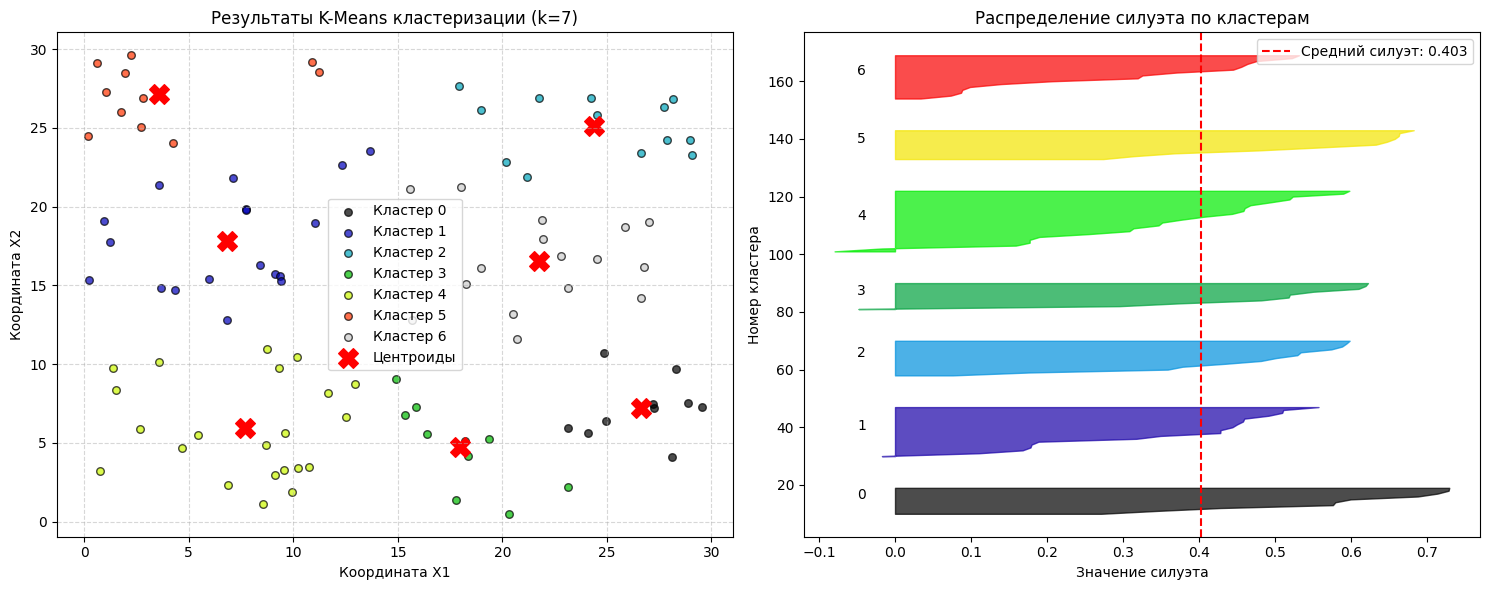

In [5]:
plt.figure(figsize=(15, 6))

# Подграфик 1: Результаты кластеризации (точки + центроиды)
plt.subplot(1, 2, 1)
# Генерируем цвета для кластеров
colors = cm.get_cmap('nipy_spectral', k)
for i in range(k):
    # Рисуем точки, принадлежащие кластеру i
    plt.scatter(X[cluster_labels == i, 0], X[cluster_labels == i, 1], 
                c=[colors(i)], label=f'Кластер {i}', s=30, edgecolors='k', alpha=0.7)

# Рисуем центроиды (центры кластеров) красными крестами
centers = kmeans_model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=1, marker='X', label='Центроиды')
plt.title(f'Результаты K-Means кластеризации (k={k})')
plt.xlabel('Координата X1')
plt.ylabel('Координата X2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Подграфик 2: Анализ коэффициента силуэта
plt.subplot(1, 2, 2)
sample_silhouette_values = silhouette_samples(X, cluster_labels)

y_lower = 10
for i in range(k):
    # Сортируем коэффициенты силуэта для текущего кластера
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # Добавляем отступ между кластерами

plt.xlabel("Значение силуэта")
plt.ylabel("Номер кластера")
plt.axvline(x=silhouette_avg, color="red", linestyle="--", 
            label=f'Средний силуэт: {silhouette_avg:.3f}')
plt.title("Распределение силуэта по кластерам")
plt.legend()

plt.tight_layout()
plt.show()

 --- 5. Ответ на вопрос домашнего задания ---

Анализ результатов кластеризации (для отчета)
1. Визуальный анализ (Левый график):
На левом графике представлены результаты работы алгоритма K-Means с параметром k=7 . Мы видим, что алгоритм разделил данные на 7 кластеров, обозначенных разными цветами. Красные крестики указывают на центроиды кластеров.
Наблюдение: Алгоритм пытается аппроксимировать кластеры сферическими областями. Мы можем заметить проблемы в областях, где кластеры имеют разную плотность или сложную форму. Например, K-Means некорректно разделил некоторые естественные группы или отнес выбросы (изолированные точки) к ближайшим плотным кластерам, исказив положение их центроидов.
2. Анализ силуэтов (Правый график):
Правый график показывает профиль силуэта для каждого кластера. Средний коэффициент силуэта составляет 0.403.
Интерпретация: Значение 0.403 является относительно низким (идеальное значение — 1.0, а значения ниже 0.5 часто указывают на нечеткую или некорректную кластеризацию).
Детали: Некоторые кластеры (например, кластер 0 и кластер 6) имеют широкий разброс значений силуэта, и часть точек имеет значения, близкие к нулю или даже отрицательные (хотя на графике отрицательных значений почти не видно, низкие значения указывают на пограничное положение точек). Это говорит о том, что форма кластеров отличается от сферической, что является известным ограничением метода K-Means.
3. Ответ на вопрос задания (Ограничения алгоритма):
Справился ли алгоритм? Нет, алгоритм не справился с задачей идеальной кластеризации данного набора данных.
Что его ограничило? Основным ограничением является гипотеза о компактности и сферичности кластеров. Набор данных aggregation.txt содержит кластеры с разной плотностью и невыпуклой формой. K-Means, минимизируя внутрикластерное расстояние, "режет" крупные кластеры или не может корректно выделить кластеры сложной формы, так как он предполагает, что все кластеры имеют примерно одинаковый размер и форму шара.

观察：“我观察到 Aggregation 数据集包含不同密度的区域，且存在孤立点。”
理论：“K-Means 算法基于距离最小化，它倾向于寻找大小相近、密度均匀的球形簇。”
结论：“由于数据的真实分布与算法的假设不符，K-Means 无法完美处理该数据集。特别是对于稀疏区域和密集区域的交界处，算法表现较差。”